# Notebook 01 — Universo de Activos

**Objetivo:** Descargar precios históricos (2007-2026) de 33 activos diversificados, limpiar los datos y construir la base de retornos diarios que alimentará el resto del pipeline.

**Universo:** Renta variable USA e internacional, renta fija, materias primas, REITs y ETFs sectoriales.

**Outputs:**
- `prices_clean.parquet` — precios ajustados limpios
- `returns_daily.parquet` — log-retornos diarios
- `macro_data.parquet` — VIX, S&P 500, bono 10Y
- `asset_universe.json` — metadatos del universo

In [1]:
%matplotlib inline
import sys, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

def _resolve_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'data').exists() and (c / 'src').exists(): return c
    return cwd

ROOT          = _resolve_root()
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIG_DIR       = ROOT / 'data' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {ROOT}')

Project root: C:\Users\Usuario\Documents\TFG\tfg_xiker_code


## 1. Universo de activos

Se seleccionan 33 instrumentos cubriendo 6 clases de activo para construir carteras diversificadas internacionalmente:

In [2]:
from src.nb01_data import TICKERS, ASSET_CLASSES, BROAD

class_counts = pd.Series(ASSET_CLASSES).value_counts()
print(f'Total tickers: {len(TICKERS)}')
print('\nDistribución por clase:')
for cls, n in class_counts.items():
    print(f'  {cls}: {n}')

Total tickers: 33

Distribución por clase:
  US Equities: 10
  International Equities: 6
  Fixed Income: 6
  Sector ETFs: 5
  Commodities: 4
  REITs: 2


## 2. Descarga de precios

Descarga de Yahoo Finance con `auto_adjust=True` (precios ajustados por dividendos y splits):

In [3]:
from src.nb01_data import download_prices, download_macro

START_DATE, END_DATE = '2007-01-01', '2026-04-30'
raw   = download_prices(TICKERS, START_DATE, END_DATE)
macro = download_macro(START_DATE, END_DATE)
print(f'\nMacro indicadores: {list(macro.columns)}')
macro.tail(3)

Raw download: (4861, 33)
  VIX: 4861 rows
  S&P 500: 4861 rows
  10Y Treasury: 4859 rows

Macro indicadores: ['VIX', 'S&P 500', '10Y Treasury']


,VIX,S&P 500,10Y Treasury
Date,,,
2026-04-27,18.020000,715.169983,4.336
2026-04-28,17.830000,711.690002,4.354
2026-04-29,18.809999,711.580017,4.418


## 3. Limpieza de precios

Se eliminan activos con >10% de datos faltantes, se rellenan huecos cortos (≤5 días) con forward-fill, y se neutralizan retornos extremos (|r|>60%) sustituyendo por NaN y volviendo a interpolar:

In [4]:
from src.nb01_data import clean_prices, compute_returns

prices  = clean_prices(raw)
returns = compute_returns(prices)
print(f'\nRango: {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Activos finales: {list(prices.columns)}')

Clean prices: (4794, 33)  [2007-04-11 -> 2026-04-29]
Returns: (4793, 33)

Rango: 2007-04-12 → 2026-04-29
Activos finales: ['AAPL', 'AMZN', 'BND', 'DBA', 'EEM', 'EWG', 'EWJ', 'EWU', 'GLD', 'GOOGL', 'HYG', 'IEF', 'IYR', 'JNJ', 'JPM', 'LQD', 'MSFT', 'NVDA', 'PG', 'SHY', 'SLV', 'TLT', 'USO', 'VGK', 'VNQ', 'VWO', 'WMT', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV', 'XOM']


## 4. Estadísticas descriptivas

Resumen anualizado de cada activo: rentabilidad, volatilidad, Sharpe, máximo drawdown, asimetría y curtosis.

In [5]:
from src.nb01_data import compute_summary_stats

stats = compute_summary_stats(returns)
stats.round(4)

,ann_return,ann_volatility,sharpe_ratio,max_drawdown,skewness,kurtosis
Ticker,,,,,,
AAPL,0.2407,0.3130,0.7690,-0.6743,-0.3141,7.0037
AMZN,0.2544,0.3739,0.6804,-0.7184,0.6683,10.5858
BND,0.0301,0.0522,0.5772,-0.1885,-0.6408,34.2004
DBA,0.0147,0.1660,0.0884,-0.7338,-0.3654,5.9906
EEM,0.0444,0.2789,0.1590,-0.7335,0.0697,16.6800
EWG,0.0408,0.2566,0.1590,-0.6812,-0.2212,11.1890
EWJ,0.0381,0.2058,0.1850,-0.5767,-0.0517,10.7147
EWU,0.0355,0.2315,0.1535,-0.6909,-0.6174,14.7287
GLD,0.0961,0.1805,0.5326,-0.4922,-0.4218,7.3807


**Interpretación:** Los activos de renta variable USA muestran los Sharpe más altos del universo. La renta fija (TLT, IEF) muestra Sharpe moderado con baja volatilidad. Las materias primas (USO, SLV) presentan alta volatilidad y Sharpe negativo en el período, reflejando la complejidad de su inclusión en carteras. Los REITs ofrecen un perfil intermedio con exposición al mercado inmobiliario.

## 5. Visualizaciones

Saved: C:\Users\Usuario\Documents\TFG\tfg_xiker_code\data\results\figures\01_universe_v2.png


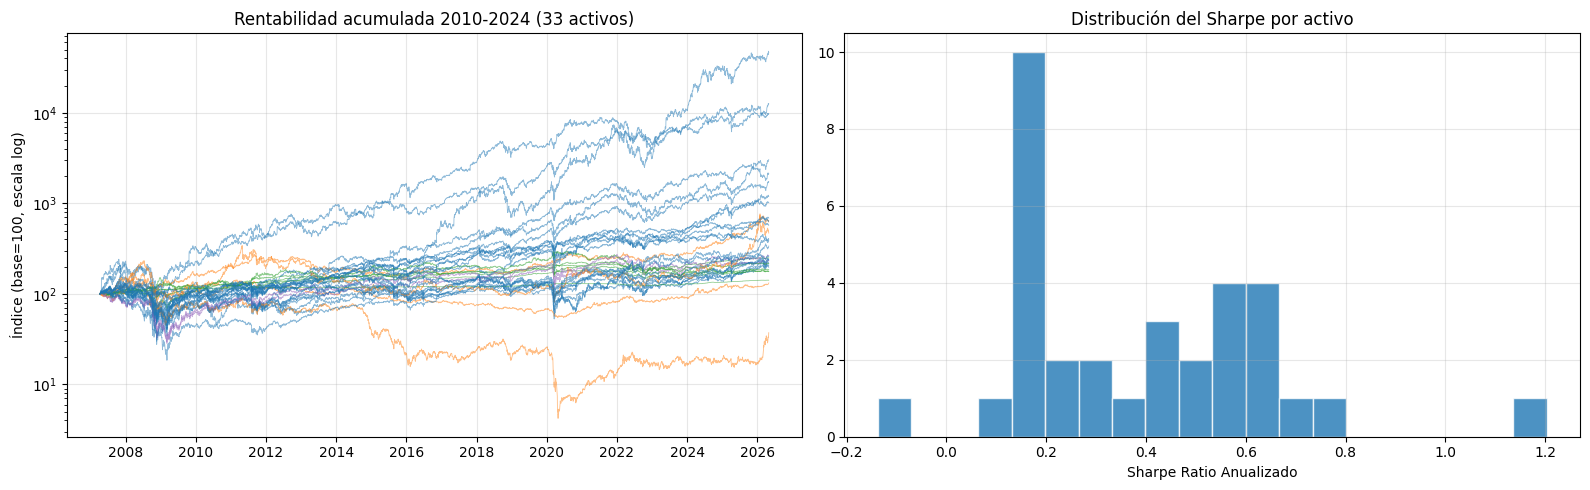

In [6]:
from src.nb01_data import plot_universe

fig = plot_universe(prices, stats, FIG_DIR)
plt.show()

**Interpretación:** El panel izquierdo muestra la rentabilidad acumulada en escala logarítmica. Se observa la clara divergencia entre renta variable (azul, mayor crecimiento) y activos defensivos. La crisis de 2020 (COVID) es visible como una caída abrupta seguida de una recuperación acelerada. El panel derecho confirma que la mayoría de activos tienen Sharpe entre 0.2 y 0.8, con algunos valores atípicos negativos (commodities).

## 6. Guardado de outputs

In [7]:
from src.nb01_data import build_asset_universe_meta, save_outputs

universe = build_asset_universe_meta(prices)
save_outputs(prices, returns, macro, universe, PROCESSED_DIR)
print(f'\n✓ NB01 COMPLETO — {len(prices.columns)} activos, {len(prices)} días (2010-2024)')

Saved prices_clean.parquet (4794, 33)
Saved returns_daily.parquet (4793, 33)
Saved macro_data.parquet (4861, 3)
Saved asset_universe.json (33 tickers)

✓ NB01 COMPLETO — 33 activos, 4794 días (2010-2024)
